# Compare Runs

Load every `summary.json` under `results/` and visualize entity-level F1, per-class F1, precision/recall, and training time across runs.

In [11]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR

PosixPath('/Users/dayanbattulga/Desktop/personal-code/misc/dunedain_ner/results')

In [12]:
summary_paths = sorted(RESULTS_DIR.glob('*/summary.json'))
print(f'Found {len(summary_paths)} summary.json files:')
for p in summary_paths:
    print(' -', p.relative_to(REPO_ROOT))

Found 22 summary.json files:
 - results/efficient_after_dapt_logit_ensemble/summary.json
 - results/efficient_after_dapt_logit_ensemble_local/summary.json
 - results/efficient_after_dapt_seed5768/summary.json
 - results/efficient_after_dapt_seed78516/summary.json
 - results/efficient_after_dapt_seed88/summary.json
 - results/efficient_after_dapt_vote_ensemble/summary.json
 - results/efficient_training_seed5768/summary.json
 - results/efficient_training_seed78516/summary.json
 - results/efficient_training_seed88/summary.json
 - results/efficient_training_vote_ensemble/summary.json
 - results/phase_b_teacher_seed5768/summary.json
 - results/phase_b_teacher_seed78516/summary.json
 - results/phase_b_teacher_seed88/summary.json
 - results/student_distilled_logit_ensemble/summary.json
 - results/student_distilled_logit_ensemble_local/summary.json
 - results/student_distilled_seed5768/summary.json
 - results/student_distilled_seed78516/summary.json
 - results/student_distilled_seed88/summary.

In [13]:
def load_summary(path: Path) -> dict:
    with open(path) as f:
        data = json.load(f)
    cfg = data.get('config', {})
    val = data.get('val_metrics', {}) or {}
    test = data.get('test_metrics', {}) or {}
    val_per = val.get('entity_per_class', {})
    test_per = test.get('entity_per_class', {})
    return {
        'run_id': data.get('run_id', path.parent.name),
        'model': cfg.get('model_name'),
        'seed': cfg.get('resolved_seed', (cfg.get('seeds') or [None])[0]),
        'use_crf': cfg.get('use_crf', False),
        'num_epochs': cfg.get('num_epochs'),
        'lr': cfg.get('learning_rate'),
        'param_count': data.get('param_count'),
        'train_time_min': data.get('train_time_min'),
        'best_val_entity_f1': data.get('best_validation_entity_f1'),
        'val_token_f1': val.get('token_weighted_f1'),
        'val_entity_f1': val.get('entity_overall_f1'),
        'val_entity_precision': val.get('entity_overall_precision'),
        'val_entity_recall': val.get('entity_overall_recall'),
        'val_per_f1': val_per.get('PER'),
        'val_loc_f1': val_per.get('LOC'),
        'val_org_f1': val_per.get('ORG'),
        'test_token_f1': test.get('token_weighted_f1'),
        'test_entity_f1': test.get('entity_overall_f1'),
        'test_entity_precision': test.get('entity_overall_precision'),
        'test_entity_recall': test.get('entity_overall_recall'),
        'test_per_f1': test_per.get('PER'),
        'test_loc_f1': test_per.get('LOC'),
        'test_org_f1': test_per.get('ORG'),
    }

rows = [load_summary(p) for p in summary_paths]
df = pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)
df

,run_id,model,seed,use_crf,num_epochs,lr,param_count,train_time_min,best_val_entity_f1,val_token_f1,...,val_per_f1,val_loc_f1,val_org_f1,test_token_f1,test_entity_f1,test_entity_precision,test_entity_recall,test_per_f1,test_loc_f1,test_org_f1
0,efficient_after_dapt_logit_ensemble,None,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.986570,0.863388,0.828226,0.901668,0.956370,0.858974,0.820643
1,efficient_after_dapt_logit_ensemble_local,None,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.986570,0.863388,0.828226,0.901668,0.956370,0.858974,0.820643
2,efficient_after_dapt_seed5768,./results/dapt_roberta-large/checkpoint-final,5768.0,True,5.0,0.00003,355366982.0,6.741237,0.928926,0.990736,...,0.978261,0.933673,0.900369,0.985878,0.851402,0.813600,0.892888,0.930796,0.854400,0.811130
3,efficient_after_dapt_seed78516,./results/dapt_roberta-large/checkpoint-final,78516.0,True,5.0,0.00003,355366982.0,6.870899,0.918740,0.989414,...,0.960289,0.953608,0.872458,0.985864,0.858844,0.832646,0.886743,0.945709,0.865478,0.812715
4,efficient_after_dapt_seed88,./results/dapt_roberta-large/checkpoint-final,88.0,True,5.0,0.00003,355366982.0,6.836513,0.915033,0.988737,...,0.974729,0.941476,0.866426,0.985954,0.854280,0.814490,0.898156,0.951049,0.860800,0.804674
5,efficient_after_dapt_vote_ensemble,None,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.986291,0.858700,0.821830,0.899034,0.949389,0.858974,0.814815
6,efficient_training_seed5768,roberta-large,5768.0,True,5.0,0.00003,355366982.0,7.308268,0.919768,0.990423,...,0.971014,0.948718,0.872928,0.985414,0.842414,0.805934,0.882353,0.935201,0.839937,0.798986
7,efficient_training_seed78516,roberta-large,78516.0,True,5.0,0.00003,355366982.0,7.306040,0.916460,0.989603,...,0.967742,0.953846,0.862963,0.986074,0.855335,0.823052,0.890255,0.956522,0.846276,0.810300
8,efficient_training_seed88,roberta-large,88.0,True,5.0,0.00003,355366982.0,7.315161,0.925620,0.990332,...,0.981949,0.956298,0.875000,0.985703,0.846672,0.813765,0.882353,0.945899,0.848485,0.797274
9,efficient_training_vote_ensemble,None,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.986454,0.855103,0.819646,0.893766,0.954704,0.846276,0.811224


## Overall entity F1 (validation vs test)

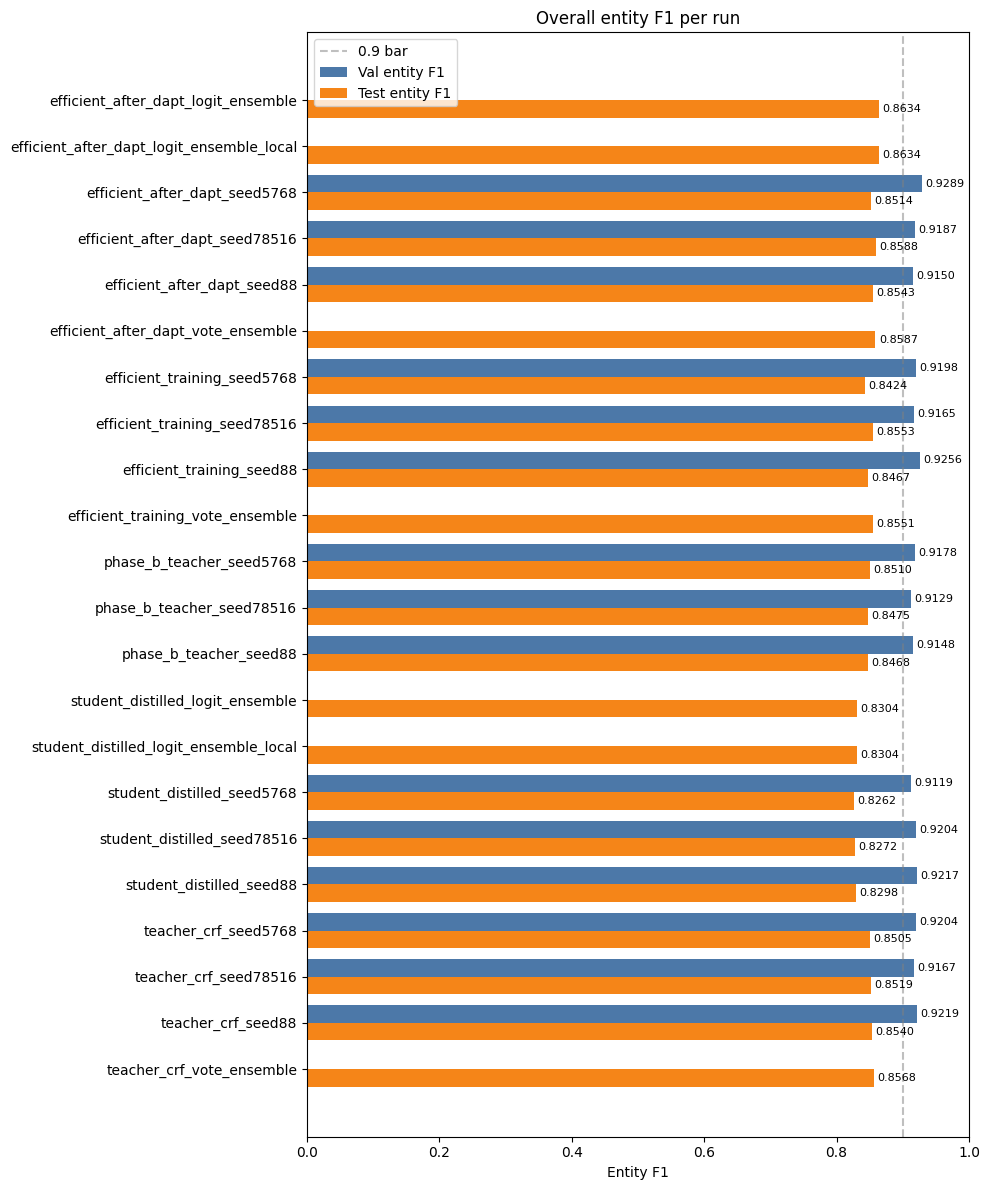

In [14]:
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.38
ax.barh(y - h/2, df['val_entity_f1'].fillna(0), h, label='Val entity F1', color='#4C78A8')
ax.barh(y + h/2, df['test_entity_f1'].fillna(0), h, label='Test entity F1', color='#F58518')
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Entity F1')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5, label='0.9 bar')
ax.legend(loc='upper left')
ax.invert_yaxis()
ax.set_title('Overall entity F1 per run')
for i, (v, t) in enumerate(zip(df['val_entity_f1'], df['test_entity_f1'])):
    if pd.notna(v):
        ax.text(v + 0.005, i - h/2, f'{v:.4f}', va='center', fontsize=8)
    if pd.notna(t):
        ax.text(t + 0.005, i + h/2, f'{t:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Per-class entity F1 on test set

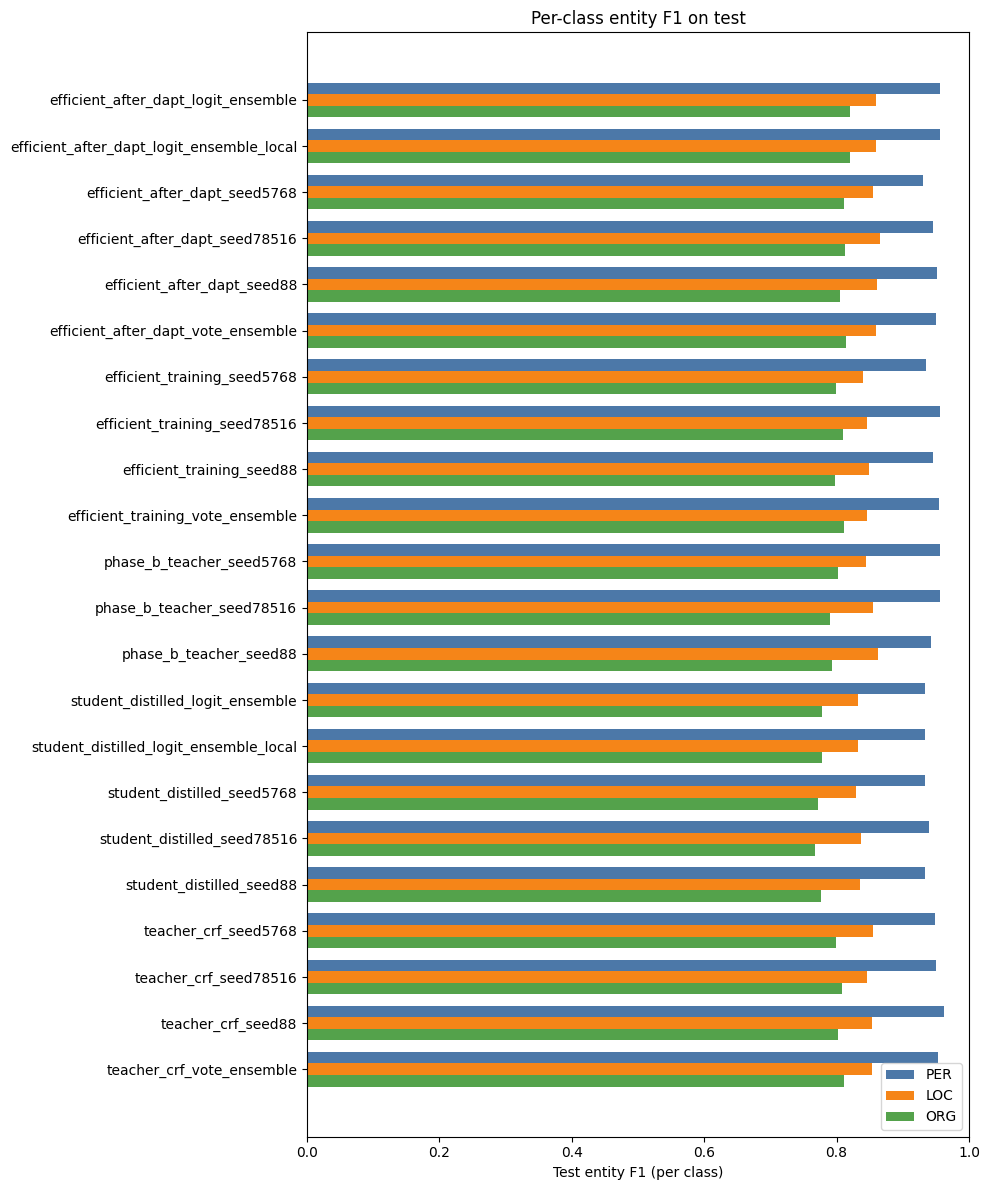

In [15]:
classes = ['PER', 'LOC', 'ORG']
cols = ['test_per_f1', 'test_loc_f1', 'test_org_f1']
fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(df) + 1)))
y = np.arange(len(df))
h = 0.25
colors = ['#4C78A8', '#F58518', '#54A24B']
for i, (c, col, color) in enumerate(zip(classes, cols, colors)):
    offset = (i - 1) * h
    ax.barh(y + offset, df[col].fillna(0), h, label=c, color=color)
ax.set_yticks(y)
ax.set_yticklabels(df['run_id'])
ax.set_xlabel('Test entity F1 (per class)')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_title('Per-class entity F1 on test')
plt.tight_layout()
plt.show()

## Train time vs test entity F1

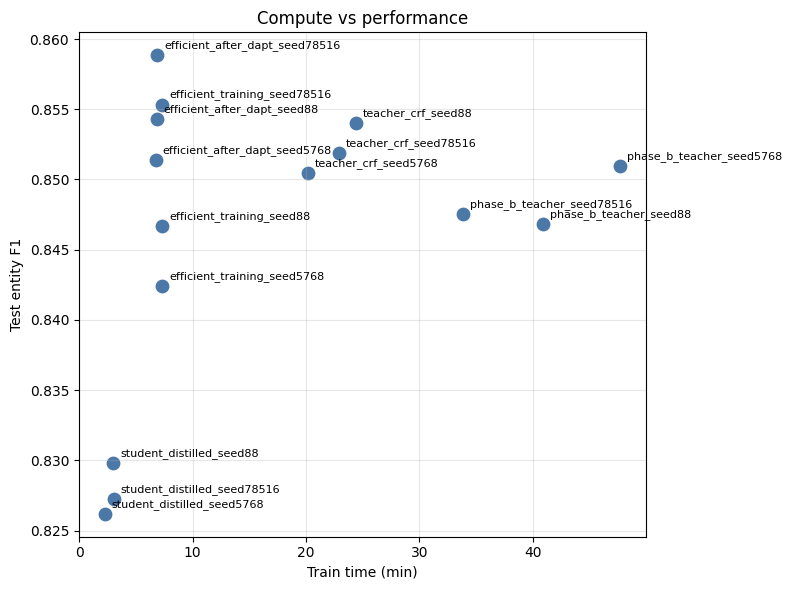

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sub = df.dropna(subset=['train_time_min', 'test_entity_f1'])
ax.scatter(sub['train_time_min'], sub['test_entity_f1'], s=80, color='#4C78A8')
for _, row in sub.iterrows():
    ax.annotate(row['run_id'], (row['train_time_min'], row['test_entity_f1']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Train time (min)')
ax.set_ylabel('Test entity F1')
ax.set_title('Compute vs performance')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Seed aggregation (mean ± std by model / variant)

In [17]:
def variant(row):
    tag = row['model'] or 'unknown'
    if row['use_crf']:
        tag += '+crf'
    return tag

df['variant'] = df.apply(variant, axis=1)
# strip seed suffix so multi-seed runs collapse
df['run_group'] = df['run_id'].str.replace(r'_seed\d+$', '', regex=True)

agg_cols = ['test_entity_f1', 'test_per_f1', 'test_loc_f1', 'test_org_f1', 'test_token_f1']
agg = df.groupby('run_group')[agg_cols].agg(['mean', 'std', 'count'])
agg

test_entity_f1                  \
                                                    mean       std count   
run_group                                                                  
efficient_after_dapt                            0.854842  0.003752     3   
efficient_after_dapt_logit_ensemble             0.863388       NaN     1   
efficient_after_dapt_logit_ensemble_local       0.863388       NaN     1   
efficient_after_dapt_vote_ensemble              0.858700       NaN     1   
efficient_training                              0.848141  0.006585     3   
efficient_training_vote_ensemble                0.855103       NaN     1   
phase_b_teacher                                 0.848451  0.002227     3   
student_distilled                               0.827747  0.001857     3   
student_distilled_logit_ensemble                0.830380       NaN     1   
student_distilled_logit_ensemble_local          0.830380       NaN     1   
teacher_crf                                     0.852132  0.001783     3   
teacher_crf_vote_ensemble                       0.856782       NaN     1   

                                          test_per_f1                  \
                                                 mean       std count   
run_group                                                               
efficient_after_dapt                         0.942518  0.010497     3   
efficient_after_dapt_logit_ensemble          0.956370       NaN     1   
efficient_after_dapt_logit_ensemble_local    0.956370       NaN     1   
efficient_after_dapt_vote_ensemble           0.949389       NaN     1   
efficient_training                           0.945874  0.010660     3   
efficient_training_vote_ensemble             0.954704       NaN     1   
phase_b_teacher                              0.951780  0.007552     3   
student_distilled                            0.935197  0.003256     3   
student_distilled_logit_ensemble             0.934028       NaN     1   
student_distilled_logit_ensemble_local       0.934028       NaN     1   
teacher_crf                                  0.953112  0.007450     3   
teacher_crf_vote_ensemble                    0.953043       NaN     1   

                                          test_loc_f1                  \
                                                 mean       std count   
run_group                                                               
efficient_after_dapt                         0.860226  0.005561     3   
efficient_after_dapt_logit_ensemble          0.858974       NaN     1   
efficient_after_dapt_logit_ensemble_local    0.858974       NaN     1   
efficient_after_dapt_vote_ensemble           0.858974       NaN     1   
efficient_training                           0.844899  0.004437     3   
efficient_training_vote_ensemble             0.846276       NaN     1   
phase_b_teacher                              0.853818  0.009169     3   
student_distilled                            0.833866  0.003966     3   
student_distilled_logit_ensemble             0.832536       NaN     1   
student_distilled_logit_ensemble_local       0.832536       NaN     1   
teacher_crf                                  0.850969  0.004845     3   
teacher_crf_vote_ensemble                    0.853968       NaN     1   

                                          test_org_f1                  \
                                                 mean       std count   
run_group                                                               
efficient_after_dapt                         0.809506  0.004259     3   
efficient_after_dapt_logit_ensemble          0.820643       NaN     1   
efficient_after_dapt_logit_ensemble_local    0.820643       NaN     1   
efficient_after_dapt_vote_ensemble           0.814815       NaN     1   
efficient_training                           0.802187  0.007078     3   
efficient_training_vote_ensemble             0.811224       NaN     1   
phase_b_teacher                              0.79535

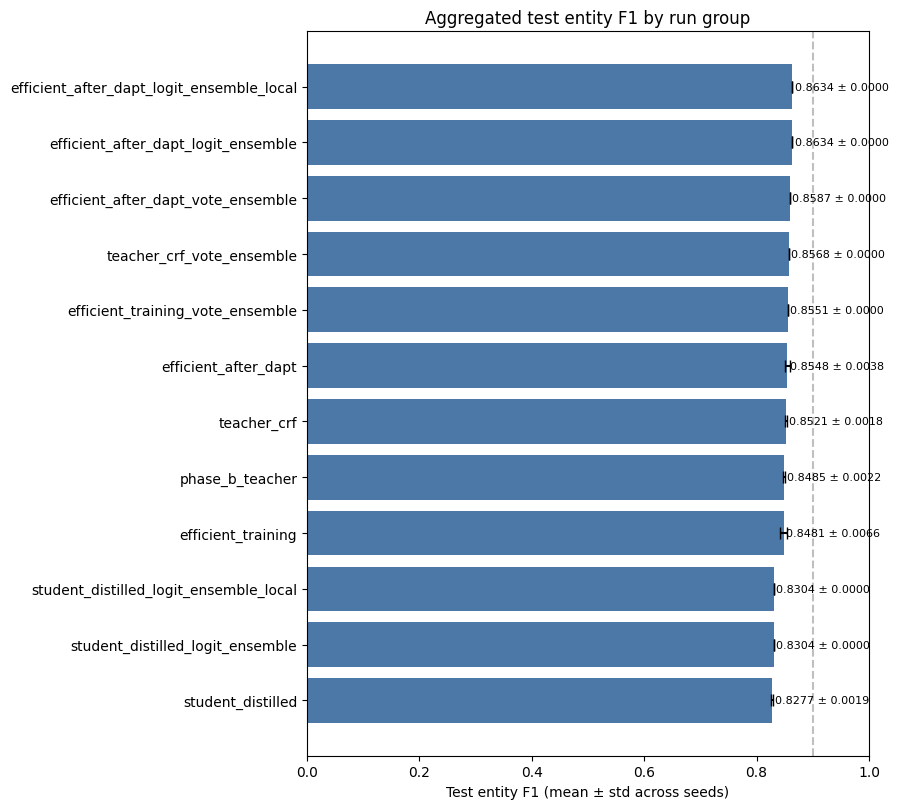

In [18]:
means = df.groupby('run_group')['test_entity_f1'].mean()
stds = df.groupby('run_group')['test_entity_f1'].std().fillna(0)
order = means.sort_values().index
fig, ax = plt.subplots(figsize=(9, max(3, 0.6 * len(order) + 1)))
y = np.arange(len(order))
ax.barh(y, means.loc[order], xerr=stds.loc[order], color='#4C78A8', capsize=4)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel('Test entity F1 (mean ± std across seeds)')
ax.set_xlim(0, 1)
ax.axvline(0.9, linestyle='--', color='gray', alpha=0.5)
ax.set_title('Aggregated test entity F1 by run group')
for i, g in enumerate(order):
    ax.text(means.loc[g] + 0.005, i, f'{means.loc[g]:.4f} ± {stds.loc[g]:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Raw comparison table

In [19]:
display_cols = ['run_id', 'model', 'seed', 'num_epochs', 'param_count', 'train_time_min',
                'best_val_entity_f1', 'val_entity_f1', 'test_entity_f1',
                'test_per_f1', 'test_loc_f1', 'test_org_f1']
df[display_cols].style.format({
    'best_val_entity_f1': '{:.4f}',
    'val_entity_f1': '{:.4f}',
    'test_entity_f1': '{:.4f}',
    'test_per_f1': '{:.4f}',
    'test_loc_f1': '{:.4f}',
    'test_org_f1': '{:.4f}',
    'train_time_min': '{:.2f}',
    'param_count': '{:,.0f}',
}, na_rep='-')

,run_id,model,seed,num_epochs,param_count,train_time_min,best_val_entity_f1,val_entity_f1,test_entity_f1,test_per_f1,test_loc_f1,test_org_f1
0,efficient_after_dapt_logit_ensemble,-,-,-,-,-,-,-,0.8634,0.9564,0.8590,0.8206
1,efficient_after_dapt_logit_ensemble_local,-,-,-,-,-,-,-,0.8634,0.9564,0.8590,0.8206
2,efficient_after_dapt_seed5768,./results/dapt_roberta-large/checkpoint-final,5768.000000,5.000000,"355,366,982",6.74,0.9289,0.9289,0.8514,0.9308,0.8544,0.8111
3,efficient_after_dapt_seed78516,./results/dapt_roberta-large/checkpoint-final,78516.000000,5.000000,"355,366,982",6.87,0.9187,0.9187,0.8588,0.9457,0.8655,0.8127
4,efficient_after_dapt_seed88,./results/dapt_roberta-large/checkpoint-final,88.000000,5.000000,"355,366,982",6.84,0.9150,0.9150,0.8543,0.9510,0.8608,0.8047
5,efficient_after_dapt_vote_ensemble,-,-,-,-,-,-,-,0.8587,0.9494,0.8590,0.8148
6,efficient_training_seed5768,roberta-large,5768.000000,5.000000,"355,366,982",7.31,0.9198,0.9198,0.8424,0.9352,0.8399,0.7990
7,efficient_training_seed78516,roberta-large,78516.000000,5.000000,"355,366,982",7.31,0.9165,0.9165,0.8553,0.9565,0.8463,0.8103
8,efficient_training_seed88,roberta-large,88.000000,5.000000,"355,366,982",7.32,0.9256,0.9256,0.8467,0.9459,0.8485,0.7973
9,efficient_training_vote_ensemble,-,-,-,-,-,-,-,0.8551,0.9547,0.8463,0.8112
